курс: Аналитик данных
# **проект №3: Дашборд конверсий**

`студент:` Иван Логвинов<br>
`наставник:` Вугар Дамиров

В рамках проекта я применяю **Python** для анализа и обработки данных, их визуализации и последующего представления полученных результатов и выводов в формате презентации.

## **Этапы проекта:**

- создание прототипа в **Jupyter Notebook** (этапы 1-2)
- чтение и запись данных из разных источников, фильтрация, агрегация и трансформация данных
- создание графиков и диаграмм с использованием библиотек **Matplotlib** и **Seaborn**
- написание скрипта на **Python** для автоматизации повторяющихся задач и экономии времени

In [2]:
import os
import pandas as pd
import requests
from dotenv import load_dotenv

# грузим переменные окружения из .env
load_dotenv()

API_URL = os.getenv("API_URL")
DATE_BEGIN = os.getenv("DATE_BEGIN")
DATE_END = os.getenv("DATE_END")

### **3. Запросы к API.**

In [4]:
# визиты
visits_resp = requests.get(f"{API_URL}/visits", params={"begin": DATE_BEGIN, "end": DATE_END})
visits = pd.DataFrame(visits_resp.json())

# регистрации
regs_resp = requests.get(f"{API_URL}/registrations", params={"begin": DATE_BEGIN, "end": DATE_END})
regs = pd.DataFrame(regs_resp.json())

### **4. Расчет метрик.**

In [6]:
# чистим ботов и дубли визитов
visits_clean = visits[~visits["user_agent"].str.contains("bot", case=False, na=False)].copy()
visits_clean = visits_clean.sort_values("datetime").drop_duplicates(subset="visit_id", keep="last")
visits_clean["date_group"] = pd.to_datetime(visits_clean["datetime"]).dt.floor("D")

# print(visits_clean.shape)

In [7]:
# группировка по дате и платформе
regs["date_group"] = pd.to_datetime(regs["datetime"]).dt.floor("D")

visits_agg = visits_clean.groupby(["date_group", "platform"]).size().reset_index(name="visits")
regs_agg = regs.groupby(["date_group", "platform"]).size().reset_index(name="registrations")

In [8]:
# считаем конверсию
conversion_df = visits_agg.merge(regs_agg, on=["date_group", "platform"], how="left")
conversion_df["registrations"] = conversion_df["registrations"].fillna(0).astype(int)
conversion_df["conversion"] = conversion_df["registrations"] / conversion_df["visits"] * 100
conversion_df = conversion_df.sort_values("date_group").reset_index(drop=True)

In [9]:
conversion_df.to_json("./conversion.json")

### **5. Добавляем рекламы.**

In [11]:
# суммирую визиты и регистрации по датам
daily_totals = conversion_df.groupby("date_group")[["visits", "registrations"]].sum().reset_index()

In [12]:
# реклама
ads = pd.read_csv("./ads.csv")
ads["date_group"] = pd.to_datetime(ads["date"]).dt.floor("D")

# приклеиваем рекламу
ads_df = daily_totals.merge(ads[["date_group", "utm_campaign", "cost"]], on="date_group", how="left")

In [13]:
# без рекламы
ads_df["cost"] = ads_df["cost"].fillna(0).astype(int)
ads_df["utm_campaign"] = ads_df["utm_campaign"].fillna("none")

In [14]:
# сортировка
ads_df = ads_df.sort_values("date_group").reset_index(drop=True)
ads_df = ads_df[["date_group", "visits", "registrations", "cost", "utm_campaign"]]

In [15]:
ads_df.to_json("./ads.json")

### **6. Визуализация.**

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

os.makedirs("./charts", exist_ok=True)

#### **6.1. Итоговые визиты.**

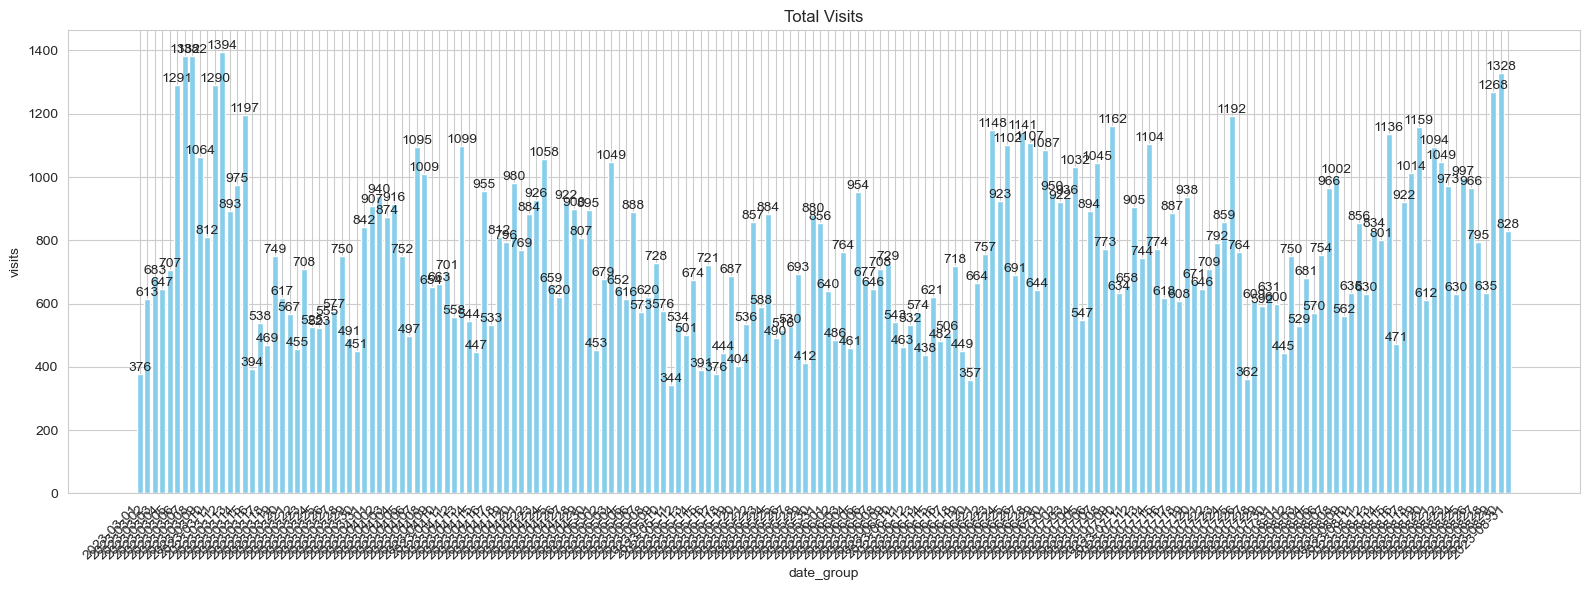

In [19]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(daily_totals["date_group"].dt.strftime("%Y-%m-%d"), daily_totals["visits"], color="skyblue")
ax.bar_label(ax.containers[0])

ax.set_title("Total Visits")
ax.set_xlabel("date_group")
ax.set_ylabel("visits")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./charts/total_visits.png")
plt.show()

#### **6.2. Итоговые визиты с разбивкой по платформам:** `web`, `android`, `ios`.

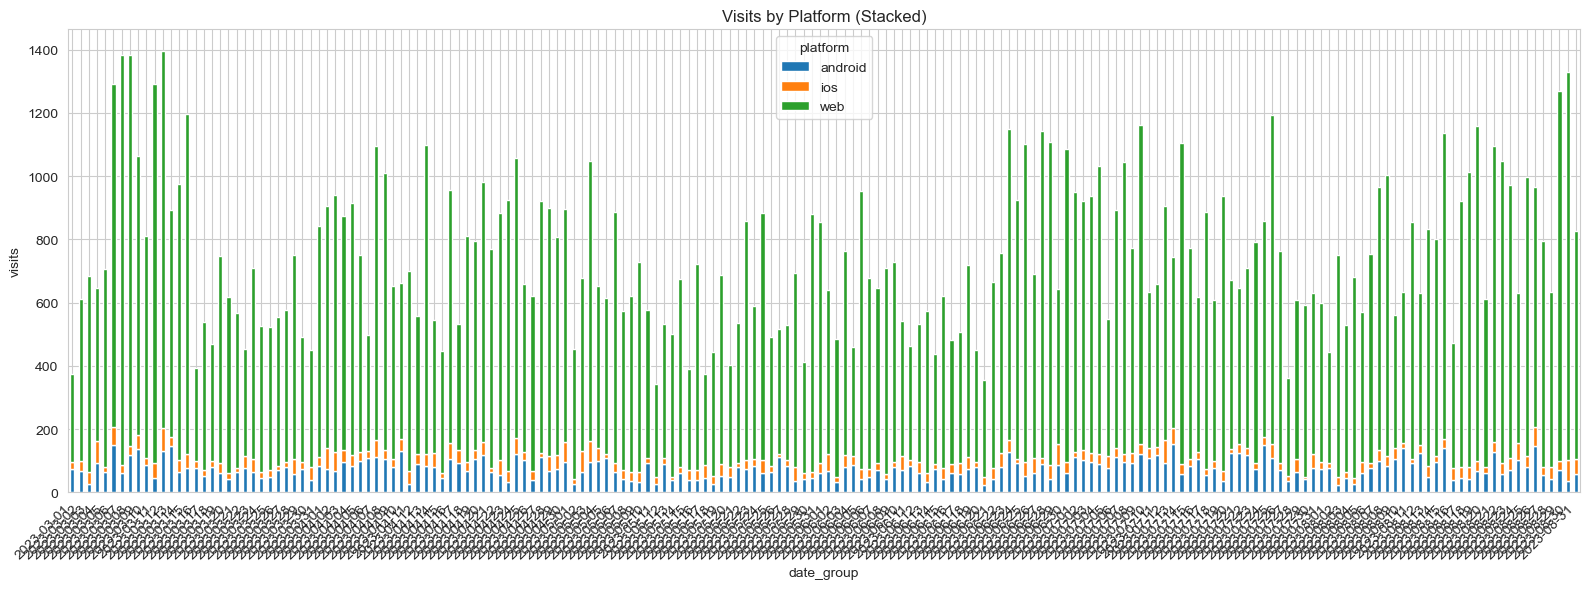

In [60]:
visits_pivot = conversion_df.pivot(index="date_group", columns="platform", values="visits")

fig, ax = plt.subplots(figsize=(16, 6))
visits_pivot.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Visits by Platform (Stacked)")
ax.set_xlabel("date_group")
ax.set_ylabel("visits")
ax.set_xticklabels(visits_pivot.index.strftime("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./charts/visits_by_platform.png")
plt.show()

#### **6.3. Итоговые регистрации.**

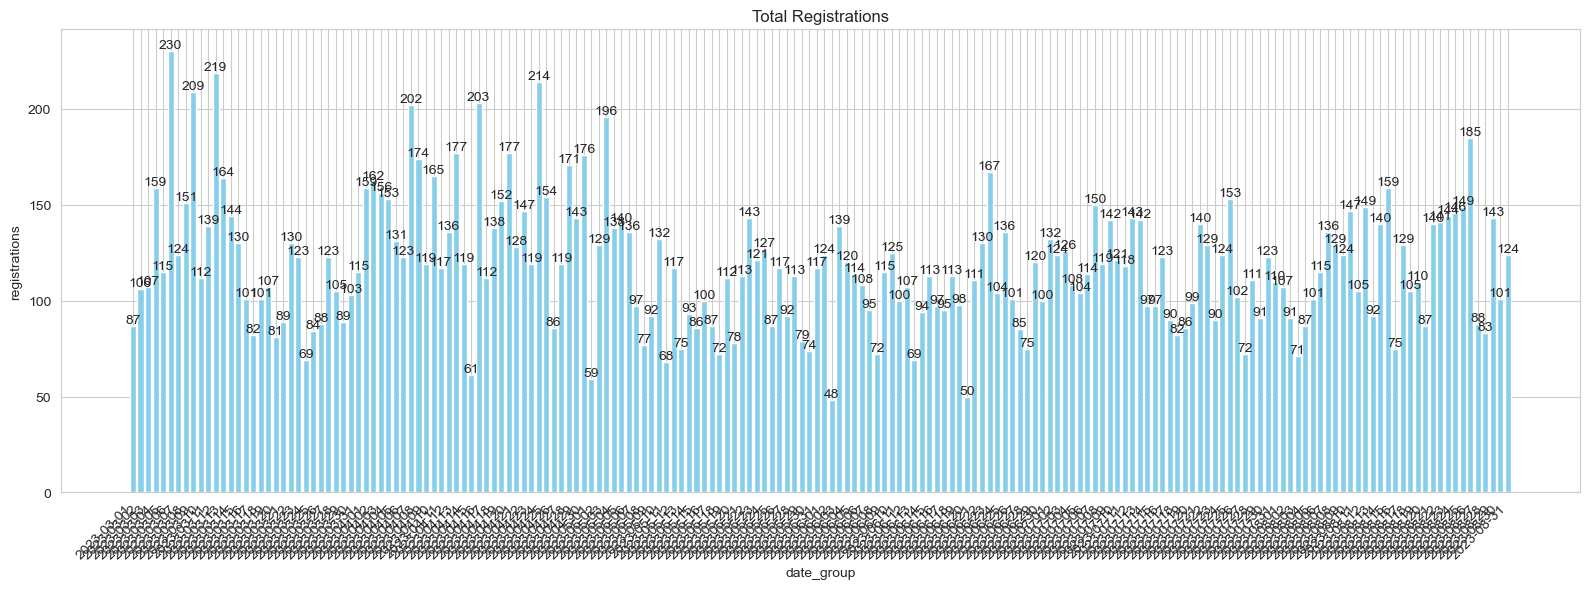

In [23]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(daily_totals["date_group"].dt.strftime("%Y-%m-%d"), daily_totals["registrations"], color="skyblue")
ax.bar_label(ax.containers[0])

ax.set_title("Total Registrations")
ax.set_xlabel("date_group")
ax.set_ylabel("registrations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./charts/total_registrations.png")
plt.show()

#### **6.4. Итоговые регистрации с разбивкой по платформам:** `web`, `android`, `ios`.

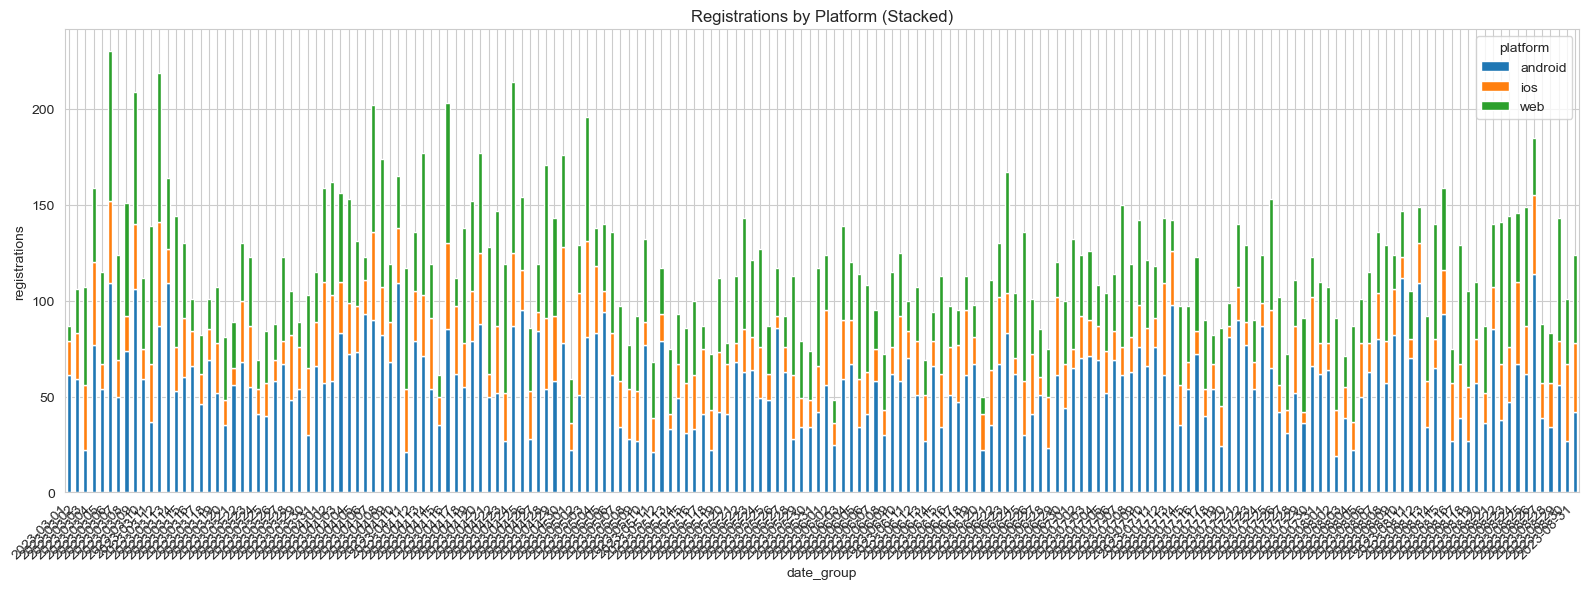

In [25]:
regs_pivot = conversion_df.pivot(index="date_group", columns="platform", values="registrations")

fig, ax = plt.subplots(figsize=(16, 6))
regs_pivot.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Registrations by Platform (Stacked)")
ax.set_xlabel("date_group")
ax.set_ylabel("registrations")
ax.set_xticklabels(regs_pivot.index.strftime("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./charts/registrations_by_platform.png")
plt.show()

#### **6.5. Конверсия по каждой платформе.**

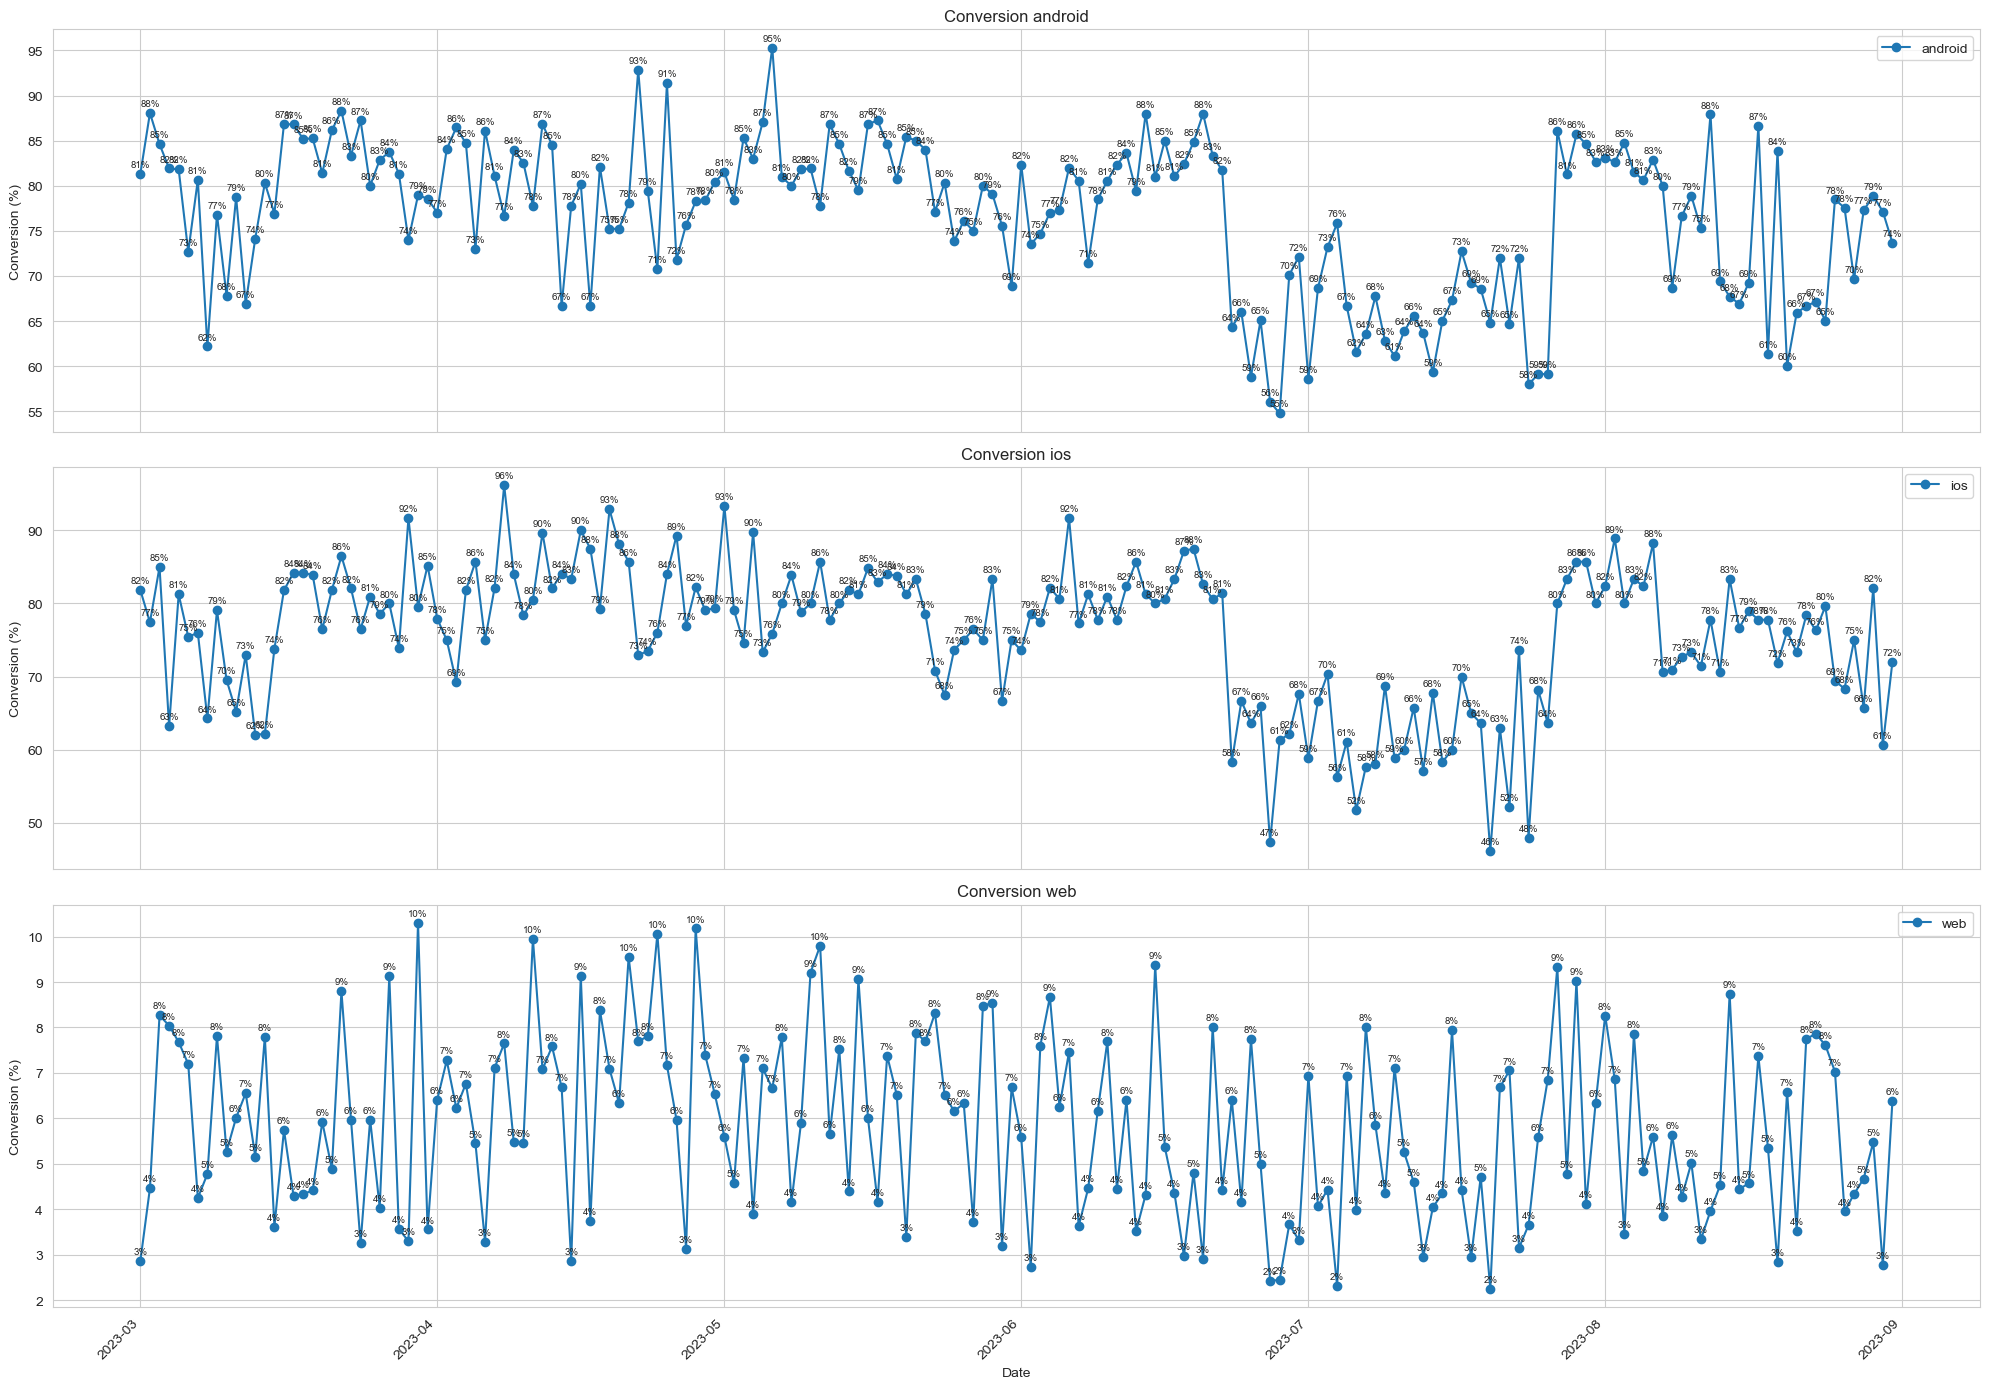

In [27]:
conv_pivot = conversion_df.pivot(index="date_group", columns="platform", values="conversion")

fig, axes = plt.subplots(3, 1, figsize=(20, 14), sharex=True)

for ax, platform in zip(axes, ["android", "ios", "web"]):
    ax.plot(conv_pivot.index, conv_pivot[platform], marker="o", label=platform)

    # подписываем каждую точку
    for x, y in zip(conv_pivot.index, conv_pivot[platform]):
        ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=7)

    ax.set_title(f"Conversion {platform}")
    ax.set_ylabel("Conversion (%)")
    ax.legend()

axes[-1].set_xlabel("Date")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./charts/conversion_by_platform.png")
plt.show()

#### **6.6. Средняя конверсия.**

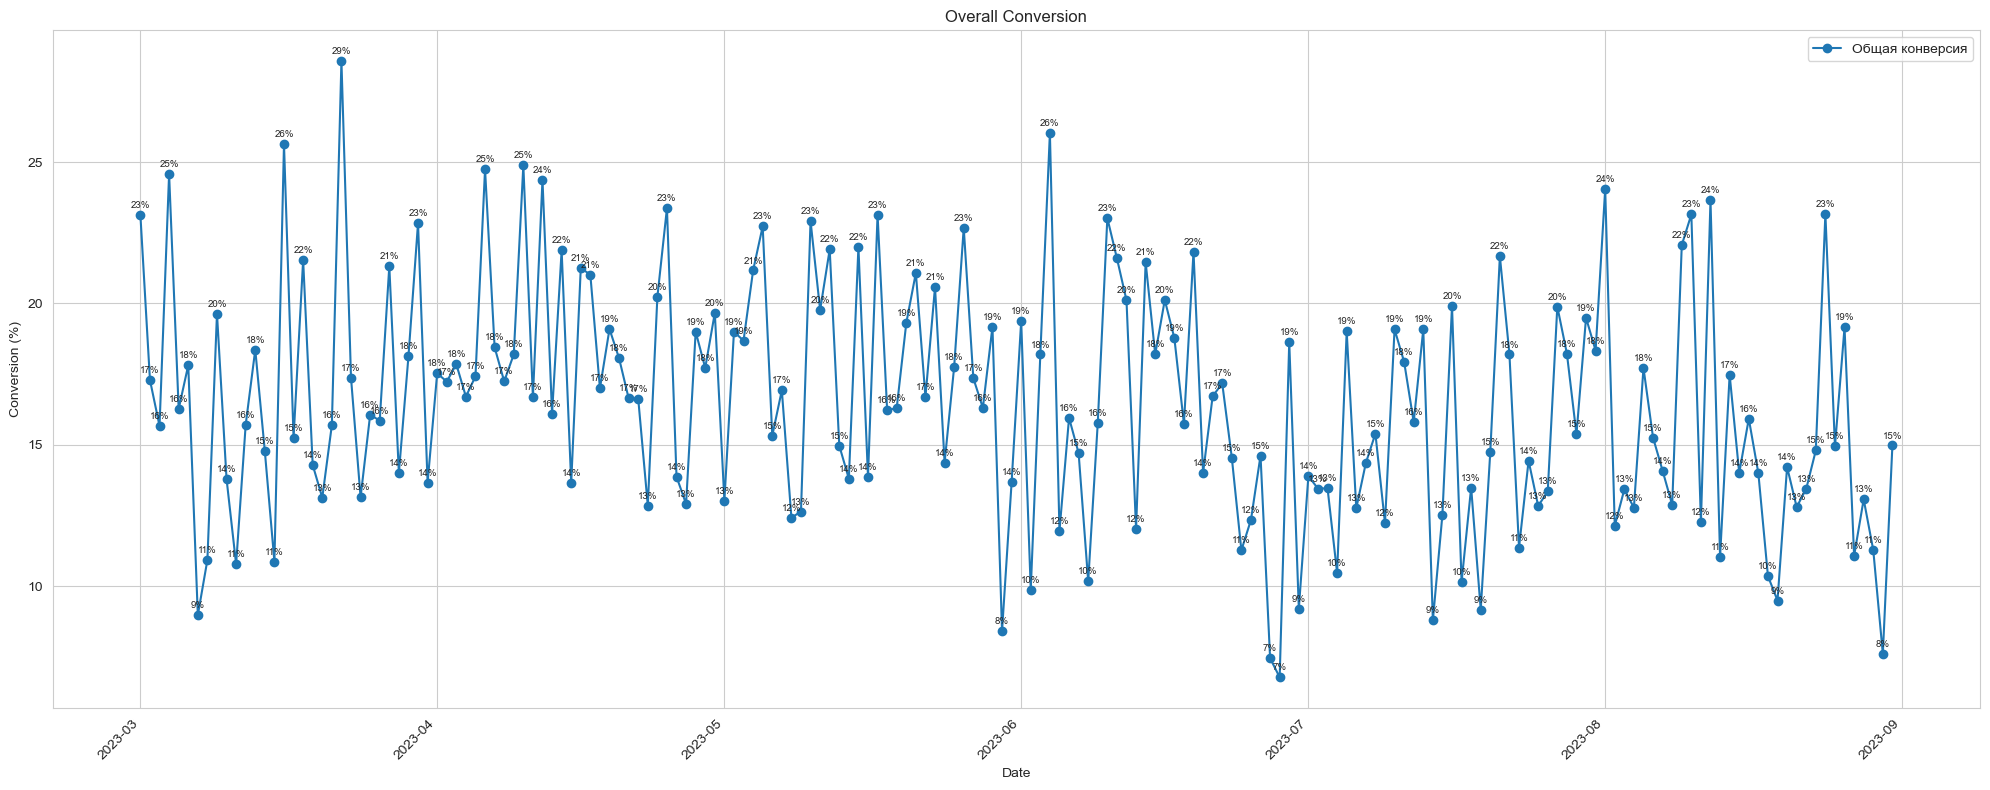

In [29]:
daily_totals["conversion"] = daily_totals["registrations"] / daily_totals["visits"] * 100

fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(daily_totals["date_group"], daily_totals["conversion"], marker="o", label="Общая конверсия")

# подписываем каждую точку
for x, y in zip(daily_totals["date_group"], daily_totals["conversion"]):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=7)

ax.set_title("Overall Conversion")
ax.set_xlabel("Date")
ax.set_ylabel("Conversion (%)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./charts/overall_conversion.png")
plt.show()

#### **6.7. Стоимости реклам.**

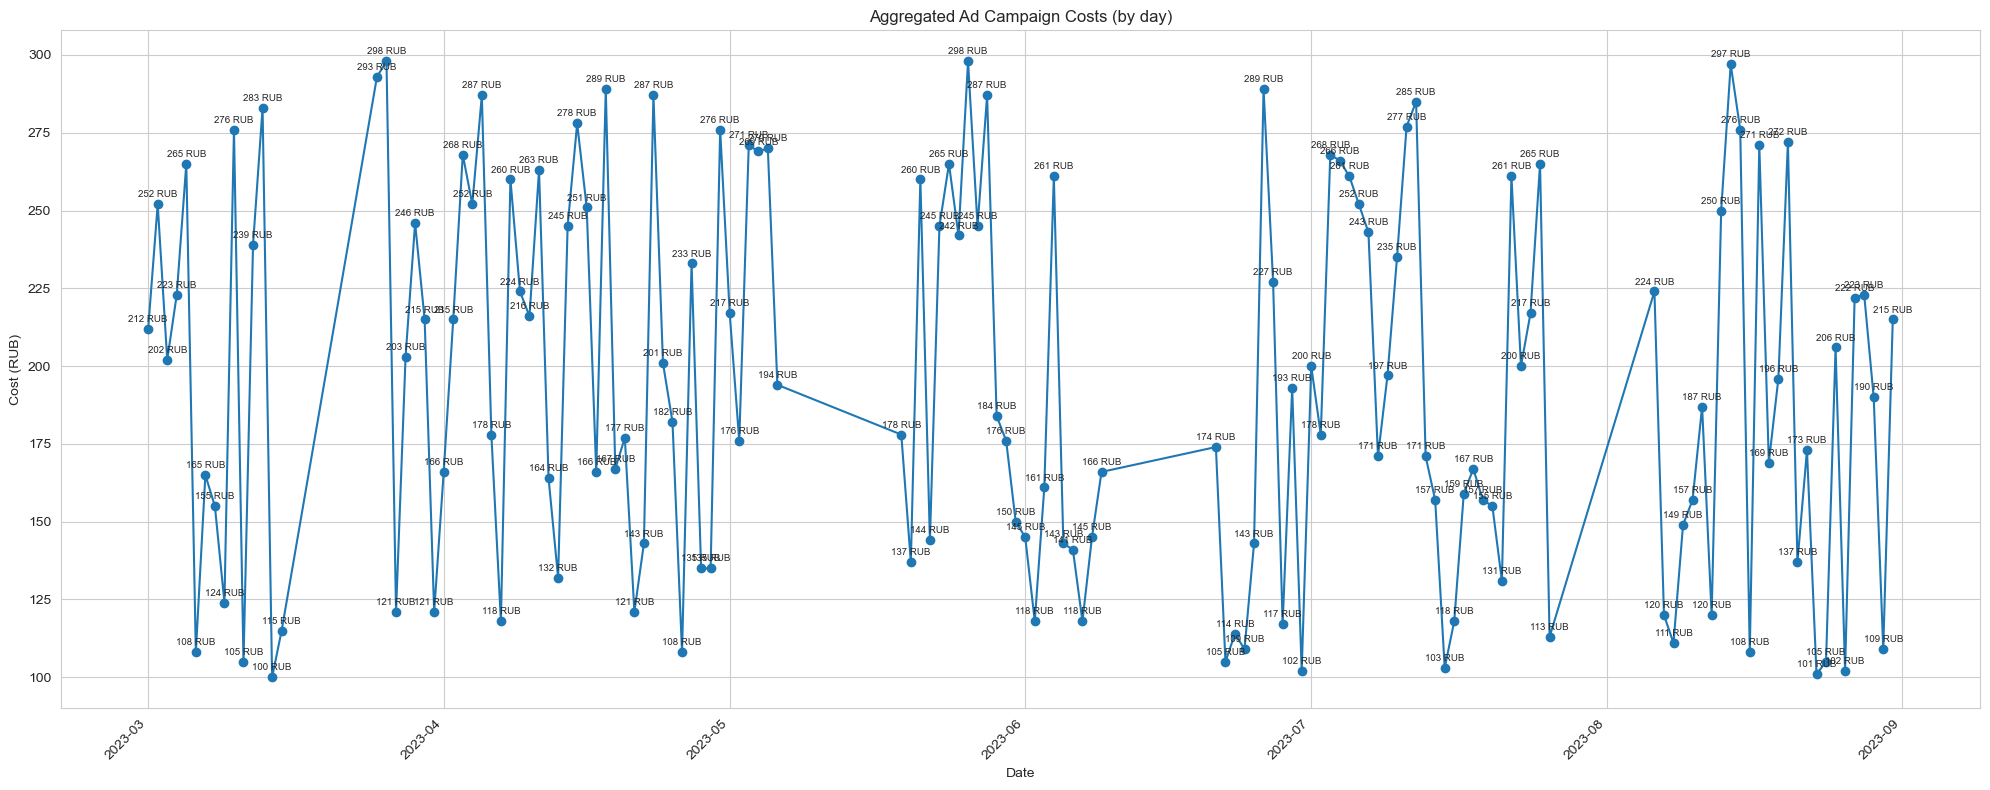

In [31]:
ads_active = ads_df[ads_df["utm_campaign"] != "none"]

fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(ads_active["date_group"], ads_active["cost"], marker="o")

# подписываем каждую точку
for x, y in zip(ads_active["date_group"], ads_active["cost"]):
    ax.annotate(f"{y} RUB", (x, y), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=7)

ax.set_title("Aggregated Ad Campaign Costs (by day)")
ax.set_xlabel("Date")
ax.set_ylabel("Cost (RUB)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./charts/ad_costs.png")
plt.show()

#### **6.8. Визиты за весь период с цветовым выделением рекламной кампании.**

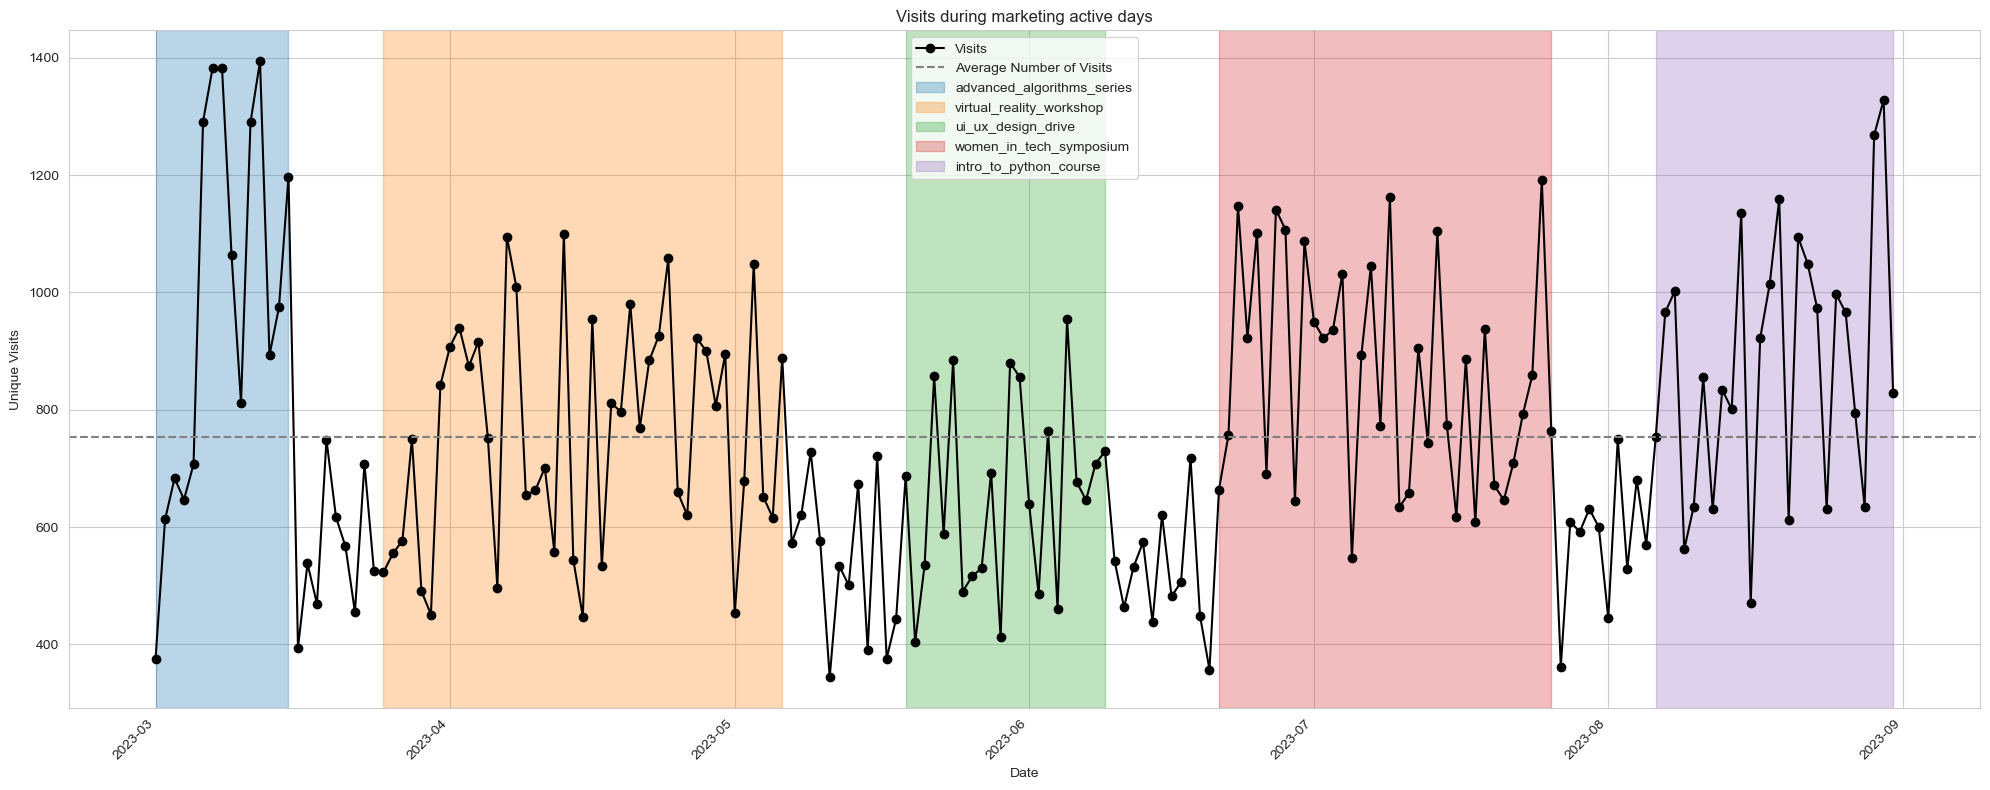

In [33]:
fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(ads_df["date_group"], ads_df["visits"], color="black", marker="o", label="Visits")
ax.axhline(ads_df["visits"].mean(), color="gray", linestyle="--", label="Average Number of Visits")

campaigns = [c for c in ads_df["utm_campaign"].unique() if c != "none"]
colors = plt.cm.tab10.colors

for i, campaign in enumerate(campaigns):
    dates = ads_df.loc[ads_df["utm_campaign"] == campaign, "date_group"]
    ax.axvspan(dates.min(), dates.max(), color=colors[i], alpha=0.3, label=campaign)

ax.set_title("Visits during marketing active days")
ax.set_xlabel("Date")
ax.set_ylabel("Unique Visits")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./charts/visits_with_campaigns.png")
plt.show()

#### **6.9. Регистрации за весь период с цветовым выделением рекламной кампании.**

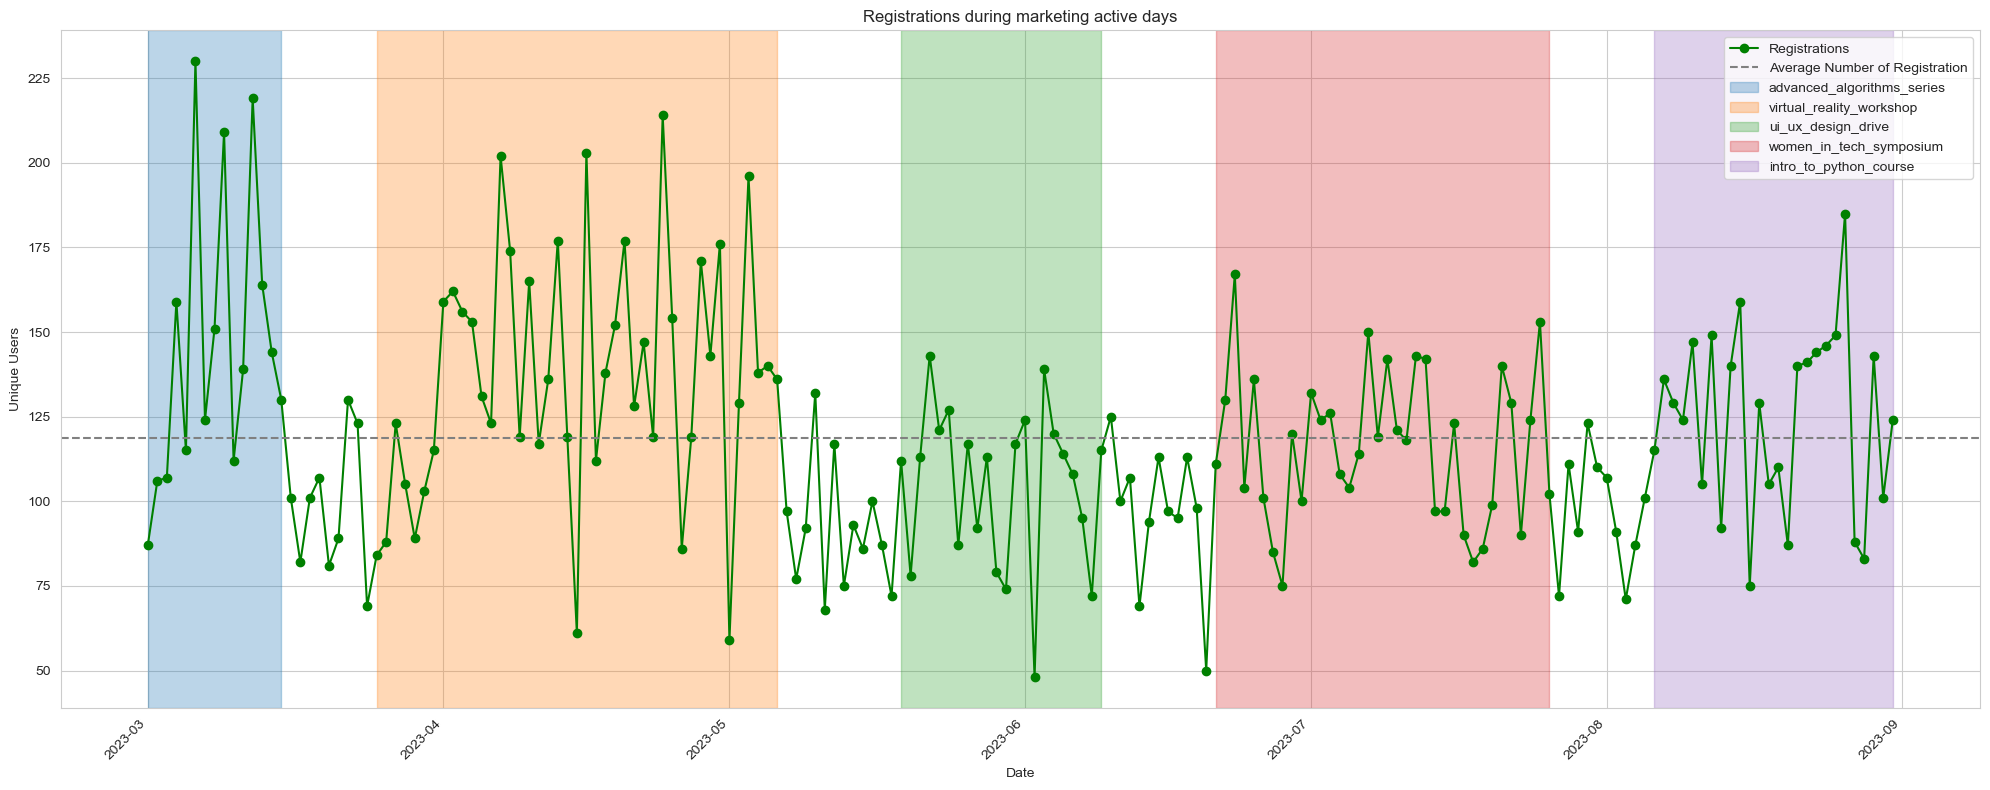

In [35]:
fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(ads_df["date_group"], ads_df["registrations"], color="green", marker="o", label="Registrations")
ax.axhline(ads_df["registrations"].mean(), color="gray", linestyle="--", label="Average Number of Registration")

campaigns = [c for c in ads_df["utm_campaign"].unique() if c != "none"]
colors = plt.cm.tab10.colors

for i, campaign in enumerate(campaigns):
    dates = ads_df.loc[ads_df["utm_campaign"] == campaign, "date_group"]
    ax.axvspan(dates.min(), dates.max(), color=colors[i], alpha=0.3, label=campaign)

ax.set_title("Registrations during marketing active days")
ax.set_xlabel("Date")
ax.set_ylabel("Unique Users")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./charts/registrations_with_campaigns.png")
plt.show()